In [454]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [455]:
# Load the dataset
df = pd.read_csv('Employee.csv')
df.head()

,Company,Age,Salary,Place,Country,Gender
0,TCS,20.0,NaN,Chennai,India,0
1,Infosys,30.0,NaN,Mumbai,India,0
2,TCS,35.0,2300.0,Calcutta,India,0
3,Infosys,40.0,3000.0,Delhi,India,0
4,TCS,23.0,4000.0,Mumbai,India,0


# Data Exploration :
Explore the data, list down the unique values in each feature and find its length.  
Perform the statistical analysis and renaming of the columns.

In [457]:
df.shape

(148, 6)

In [458]:
df.dtypes

Company     object
Age        float64
Salary     float64
Place       object
Country     object
Gender       int64
dtype: object

In [459]:
# Display unique values and their lengths

print("Unique values in each column:\n")
for col in df.columns:
    print(f"{col}:\n  Unique Values: {df[col].unique()}")
    print(f"  Count of Unique Values: {df[col].nunique(dropna=True)}\n")
    

Unique values in each column:

Company:
  Unique Values: ['TCS' 'Infosys' 'CTS' nan 'Tata Consultancy Services' 'Congnizant'
 'Infosys Pvt Lmt']
  Count of Unique Values: 6

Age:
  Unique Values: [20. 30. 35. 40. 23. nan 34. 45. 18. 22. 32. 37. 50. 21. 46. 36. 26. 41.
 24. 25. 43. 19. 38. 51. 31. 44. 33. 17.  0. 54.]
  Count of Unique Values: 29

Salary:
  Unique Values: [  nan 2300. 3000. 4000. 5000. 6000. 7000. 8000. 9000. 1089. 1234. 3030.
 3045. 3184. 4824. 5835. 7084. 8943. 8345. 9284. 9876. 2034. 7654. 2934.
 4034. 5034. 8202. 9024. 4345. 6544. 6543. 3234. 4324. 5435. 5555. 8787.
 3454. 5654. 5009. 5098. 3033.]
  Count of Unique Values: 40

Place:
  Unique Values: ['Chennai' 'Mumbai' 'Calcutta' 'Delhi' 'Podicherry' 'Cochin' nan 'Noida'
 'Hyderabad' 'Bhopal' 'Nagpur' 'Pune']
  Count of Unique Values: 11

Country:
  Unique Values: ['India']
  Count of Unique Values: 1

Gender:
  Unique Values: [0 1]
  Count of Unique Values: 2



In [460]:
# Statistical analysis

print('Statistical Summary')
df.describe()

Statistical Summary


,Age,Salary,Gender
count,130.000000,124.000000,148.000000
mean,30.484615,5312.467742,0.222973
std,11.096640,2573.764683,0.417654
min,0.000000,1089.000000,0.000000
25%,22.000000,3030.000000,0.000000
50%,32.500000,5000.000000,0.000000
75%,37.750000,8000.000000,0.000000
max,54.000000,9876.000000,1.000000


# Data Cleaning :
Find the missing and inappropriate values, treat them appropriately.  
Remove all duplicate rows.  
Find the outliers.  
Replace the value 0 in age as NaN  
Treat the null values in all columns using any measures(removing/ replace the values with mean/median/mode)


In [462]:
# Unique values
df['Age'].unique()

array([20., 30., 35., 40., 23., nan, 34., 45., 18., 22., 32., 37., 50.,
       21., 46., 36., 26., 41., 24., 25., 43., 19., 38., 51., 31., 44.,
       33., 17.,  0., 54.])

In [463]:
# Replace 0 in age with NaN

df['Age'].replace(0, np.nan, inplace=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_13832\2365113279.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].replace(0, np.nan, inplace=True)


In [464]:
print('Duplicated values :')
df.duplicated().sum()

Duplicated values :


4

In [465]:
# Remove duplicate rows

df.drop_duplicates(inplace=True)

In [466]:
print('Null values after replacing & removing duplicates:')
df.isnull().sum()

Null values after replacing & removing duplicates:


Company     8
Age        23
Salary     23
Place      14
Country     0
Gender      0
dtype: int64

In [467]:
# Fill missing values
# Numerical columns: Fill with median

df['Age'].fillna(df['Age'].median(), inplace=True)
df['Salary'].fillna(df['Salary'].median(), inplace=True)

# Categorical columns: Fill with mode

df['Company'].fillna(df['Company'].mode()[0], inplace=True)
df['Place'].fillna(df['Place'].mode()[0], inplace=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_13832\1266671426.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
C:\Users\USER\AppData\Local\Temp\ipykernel_13832\1266671426.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

In [468]:
# Show missing values after treatment

print("Missing values after treatment :")
df.isnull().sum()

Missing values after treatment :


Company    0
Age        0
Salary     0
Place      0
Country    0
Gender     0
dtype: int64

In [469]:
df = df.drop(columns=['Country'])
df.head()

,Company,Age,Salary,Place,Gender
0,TCS,20.0,5000.0,Chennai,0
1,Infosys,30.0,5000.0,Mumbai,0
2,TCS,35.0,2300.0,Calcutta,0
3,Infosys,40.0,3000.0,Delhi,0
4,TCS,23.0,4000.0,Mumbai,0


In [470]:
# Detect outliers using IQR method

def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers

outliers_age = detect_outliers_iqr(df, 'Age')
outliers_salary = detect_outliers_iqr(df, 'Salary')

print(f"Number of outliers in Age: {len(outliers_age)}")
print(f"Number of outliers in Salary: {len(outliers_salary)}")

Number of outliers in Age: 0
Number of outliers in Salary: 0


# Data Analysis :
Filter the data with age >40 and salary<5000  
Plot the chart with age and salary  
Count the number of people from each place and represent it visually

In [472]:
# Filter: Age > 40 and Salary < 5000

filtered_df = df[(df['Age'] > 40) & (df['Salary'] < 5000)]
print("Filtered Data (Age > 40 and Salary < 5000):\n")
filtered_df

Filtered Data (Age > 40 and Salary < 5000):



,Company,Age,Salary,Place,Gender
21,Infosys,50.0,3184.0,Delhi,0
32,Infosys,45.0,4034.0,Calcutta,0
39,Infosys,41.0,3000.0,Mumbai,0
50,Infosys,41.0,3000.0,Chennai,0
57,Infosys,51.0,3184.0,Hyderabad,0
68,Infosys,43.0,4034.0,Mumbai,0
75,Infosys,44.0,3000.0,Cochin,0
86,Infosys,41.0,3000.0,Delhi,0
93,Infosys,54.0,3184.0,Mumbai,0
104,Infosys,44.0,4034.0,Delhi,0


In [473]:
filtered_df.shape

(15, 5)

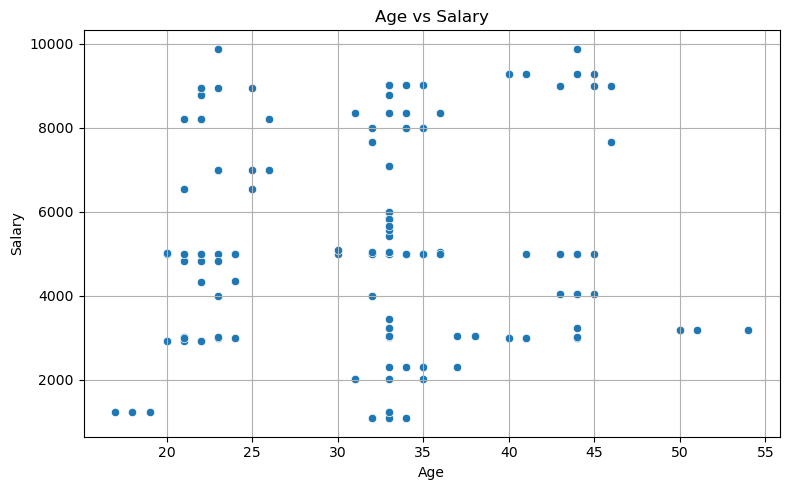

In [474]:
# Plot: Age vs Salary

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Age', y='Salary')
plt.title('Age vs Salary')
plt.xlabel('Age')
plt.ylabel('Salary')
plt.grid(True)
plt.tight_layout()
plt.show()

In [475]:
# Count of people from each place

place_counts = df['Place'].value_counts()
print('Count of people :\n',place_counts)

Count of people :
 Place
Mumbai        48
Calcutta      32
Chennai       14
Delhi         14
Cochin        13
Noida          8
Hyderabad      8
Podicherry     3
Pune           2
Bhopal         1
Nagpur         1
Name: count, dtype: int64


C:\Users\USER\AppData\Local\Temp\ipykernel_13832\1485046525.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=place_counts.values, x=place_counts.index, palette="viridis")


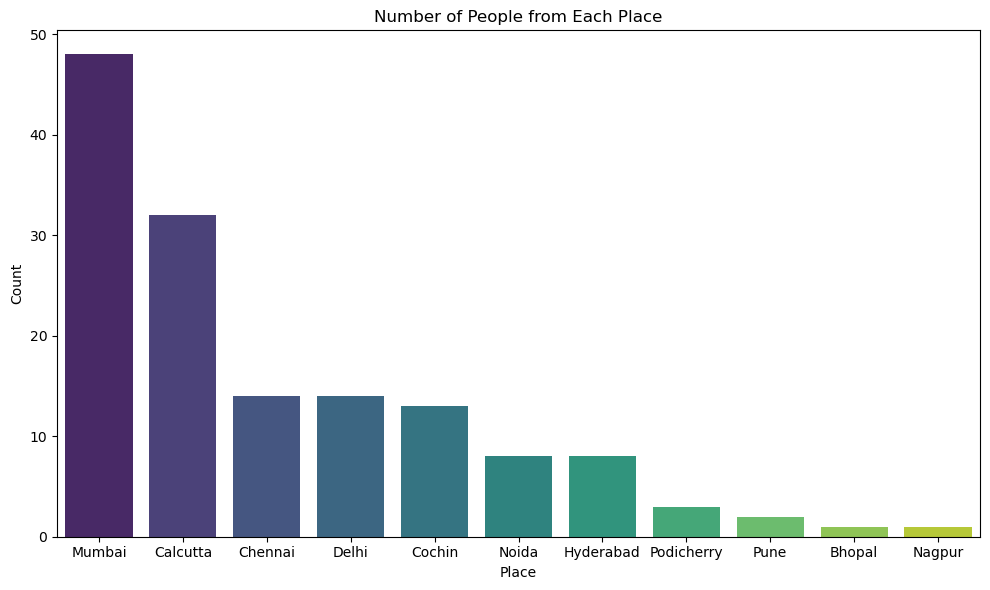

In [476]:
# Visualization
plt.figure(figsize=(10, 6))
sns.barplot(y=place_counts.values, x=place_counts.index, palette="viridis")
plt.title('Number of People from Each Place')
plt.ylabel('Count')
plt.xlabel('Place')
plt.tight_layout()
plt.show()


# Data Encoding :
Convert categorical variables into numerical representations using techniques such as one-hot encoding, label encoding, making them suitable for analysis by machine learning algorithms.

In [516]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, MinMaxScaler

In [518]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Apply Label Encoding
le = LabelEncoder()
label_encoded_df = df.copy()
for col in categorical_cols:
    label_encoded_df[col] = le.fit_transform(df[col])
label_encoded_df.head()

,Company,Age,Salary,Place,Gender
0,4,20.0,5000.0,2,0
1,2,30.0,5000.0,6,0
2,4,35.0,2300.0,1,0
3,2,40.0,3000.0,4,0
4,4,23.0,4000.0,6,0


In [520]:
# Apply One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [522]:
df_encoded.head()

,Company,Age,Salary,Place,Gender
0,4,20.0,5000.0,2,0
1,2,30.0,5000.0,6,0
2,4,35.0,2300.0,1,0
3,2,40.0,3000.0,4,0
4,4,23.0,4000.0,6,0


# Feature Scaling :
After the process of encoding, perform the scaling of the features using standardscaler and minmaxscaler.

In [559]:
# Identify numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [549]:
# Apply StandardScaler
scaler_std = StandardScaler()
df_std_scaled = df.copy()
df_std_scaled[numerical_cols] = scaler_std.fit_transform(df[numerical_cols])

print("\n Standard Scaled Numerical Features :\n")
df_std_scaled[numerical_cols].head()


 Standard Scaled Numerical Features :



,Age,Salary,Gender
0,-1.484676,-0.100827,-0.534522
1,-0.267174,-0.100827,-0.534522
2,0.341577,-1.243735,-0.534522
3,0.950328,-0.947426,-0.534522
4,-1.119426,-0.524127,-0.534522


In [545]:
# Apply MinMaxScaler
scaler_mm = MinMaxScaler()
df_mm_scaled = df.copy()
df_mm_scaled[numerical_cols] = scaler_mm.fit_transform(df[numerical_cols])

print("\n Min-Max Scaled Numerical Features:\n")
df_mm_scaled[numerical_cols].head()


 Min-Max Scaled Numerical Features:



,Age,Salary,Gender
0,0.081081,0.445089,0.0
1,0.351351,0.445089,0.0
2,0.486486,0.137817,0.0
3,0.621622,0.217480,0.0
4,0.162162,0.331285,0.0
